In [19]:
import subprocess
result = subprocess.run(['tesseract', '--version'], capture_output=True, text=True)
print(result.stdout)

# 한국어 팩 확인
result2 = subprocess.run(['tesseract', '--list-langs'], capture_output=True, text=True)
print(result2.stdout)

FileNotFoundError: [WinError 2] 지정된 파일을 찾을 수 없습니다

In [13]:
import fitz
import json
import os
from pathlib import Path

# 경로 설정
PDF_PATH = "../data/sample/2015개정경제수학-광주교육청.pdf"
OUTPUT_DIR = "../outputs"
IMAGE_DIR = os.path.join(OUTPUT_DIR, "images")

os.makedirs(IMAGE_DIR, exist_ok=True)

# PDF 열기
doc = fitz.open(PDF_PATH)
print(f"총 페이지 수: {len(doc)}")
print(f"PDF 제목: {doc.metadata.get('title', '없음')}")

총 페이지 수: 198
PDF 제목: 


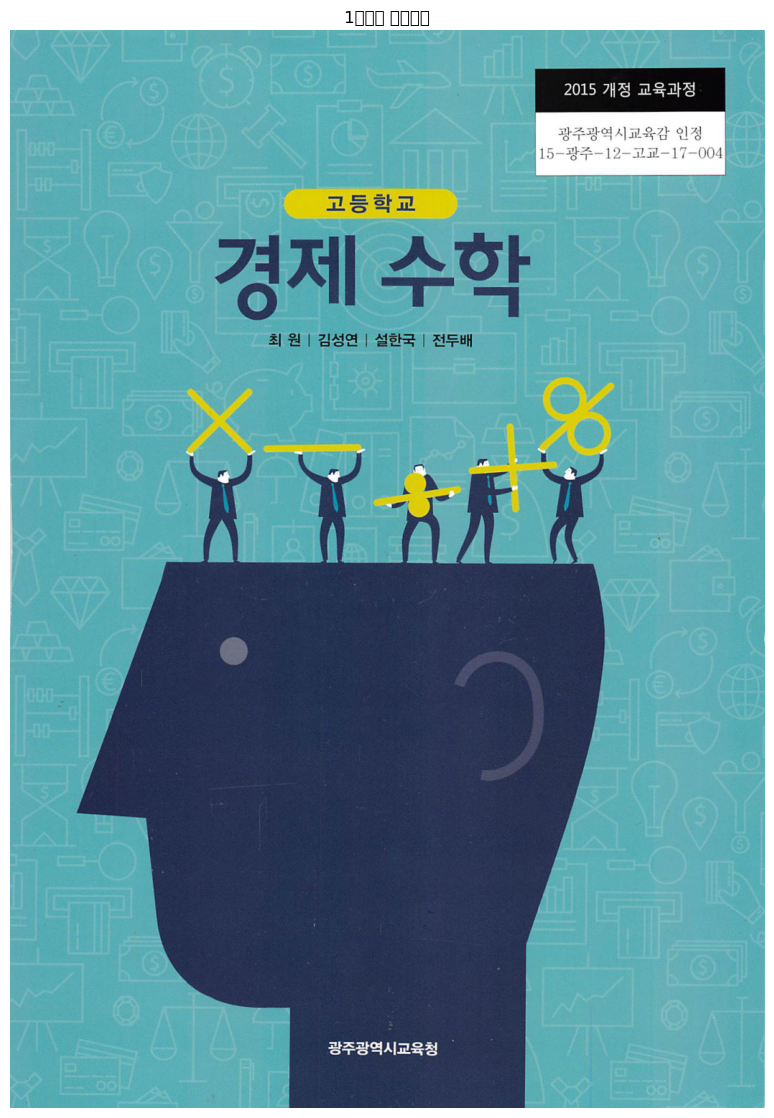

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 1페이지를 이미지로 렌더링해서 확인
page = doc[0]
pix = page.get_pixmap(dpi=150)
pix.save("preview_page1.png")

img = mpimg.imread("preview_page1.png")
plt.figure(figsize=(10, 14))
plt.imshow(img)
plt.axis("off")
plt.title("1페이지 미리보기")
plt.show()

In [17]:
page = doc[0]
blocks = page.get_text("dict")["blocks"]

for b in blocks:
    if b["type"] == 0:  # 텍스트 블록
        for line in b["lines"]:
            for span in line["spans"]:
                print(f"[폰트:{span['size']:.1f}pt / bold:{bool(span['flags']&16)}] {span['text'][:50]}")